In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
# JC-model simulation with a thermal cavity bath.
# Time unit: us, frequency unit: rad/us.
from scipy.optimize import curve_fit
from qutip import basis, destroy, mesolve, qeye, tensor
import qutip as qt

## $\Gamma$ Simulation

In [33]:
MHz = 2 * np.pi  # 1 MHz = 2*pi rad/us

# Example parameters in the dispersive regime.
N = 12                  # cavity truncation
Delta = 1000 * MHz       # qubit-cavity detuning
g = 10 * MHz  # 20,10          # JC coupling
kappa = 20.0 * MHz # 2,20       # cavity linewidth
gamma_q = 0 #0.002 * MHz   # intrinsic qubit relaxation

chi = g**2 / Delta
print(f'2 chi = {2*chi /(2*np.pi):.6f} MHz, while kappa = {kappa/(2*np.pi):.6f} MHz,'
+'\n which need to be close to each other')

a = tensor(destroy(N), qeye(2))
g_state = basis(2, 0)
e_state = basis(2, 1)
sm_q = g_state * e_state.dag()  # |g><e| in the superconducting basis
sm = tensor(qeye(N), sm_q)
pe = tensor(qeye(N), e_state * e_state.dag())  # |e><e|

# JC Hamiltonian in the cavity rotating frame.
H = Delta * pe + g * (a.dag() * sm + a * sm.dag())

n_th = 0.1
gamma_up_ideal = kappa* g**2 / Delta**2 *n_th
gamma_down_ideal = kappa* g**2 / Delta**2 *(n_th+1)
print(f"Theory : Gamma_up = {gamma_up_ideal * 1e3:.3f} kHz, Gamma_down = {gamma_down_ideal * 1e3:.3f} kHz")


2 chi = 0.200000 MHz, while kappa = 20.000000 MHz,
 which need to be close to each other
Theory : Gamma_up = 1.257 kHz, Gamma_down = 13.823 kHz


In [34]:
def simulate_population(n_th, tlist, qubit_init="g"):
    """Return qubit excited-state population for a given thermal photon number."""
    c_ops = [
        np.sqrt(kappa * (n_th + 1)) * a,
        np.sqrt(kappa * n_th) * a.dag(),
    ]
    if gamma_q > 0:
        c_ops.append(np.sqrt(gamma_q) * sm)

    q_state = g_state if qubit_init == "g" else e_state
    psi0 = tensor(qt.thermal_dm(N, n_th), q_state * q_state.dag())
    # psi0 = tensor(basis(N, 0), q_state)
    result = mesolve(H, psi0, tlist, c_ops, [pe])
    return np.asarray(result.expect[0])

def exp_decay_up(t, Gamma1, P0, Pss):
    # return Pss + (P0 - Pss) * np.exp(-Gamma1 * t)
    return Pss * (1- np.exp(-Gamma1 * t))

def exp_decay_down(t, Gamma1, P0, Pss):
    return Pss + (P0 - Pss) * np.exp(-Gamma1 * t)

def fit_gamma1(tlist, population, qubit_init="g"):
    # 初始猜测（很重要）
    P0_guess = population[0]
    Pss_guess = population[-1]
    Gamma1_guess = 1 / (tlist[-1] - tlist[0] + 1e-9)

    if qubit_init=="g":
        fit_func = exp_decay_up
    else:
        fit_func = exp_decay_down
        
    popt, pcov = curve_fit(
        fit_func,
        tlist,
        population,
        p0=[Gamma1_guess, P0_guess, Pss_guess]
    )

    Gamma1, P0, Pss = popt
    return Gamma1, P0, Pss, popt, pcov    

def fit_initial_rates(t, pop_g, pop_e, fit_tmax=0.5):
    """Fit the short-time slopes to estimate Gamma_up and Gamma_down."""
    mask = t <= fit_tmax
    if np.count_nonzero(mask) < 3:
        raise ValueError("Need at least 3 time points in the short-time fitting window.")

    t_fit = t[mask]
    pop_g_fit = pop_g[mask]
    pop_e_fit = pop_e[mask]

    coef_g = np.polyfit(t_fit, pop_g_fit, 1)
    coef_e = np.polyfit(t_fit, pop_e_fit, 1)

    gamma_up_slope = coef_g[0]
    gamma_down_slope = -coef_e[0]
    return gamma_up_slope, gamma_down_slope, coef_g, coef_e, t_fit

# def fit_initial_rates(t, pop_g, pop_e, fit_tmax=0.5):
#     mask = t <= fit_tmax
#     if np.count_nonzero(mask) < 3:
#         raise ValueError("Need at least 3 time points.")

#     t_fit = t[mask]
#     pop_g_fit = pop_g[mask]
#     pop_e_fit = pop_e[mask]

#     # --- gamma_up (截距=0) ---
#     gamma_up = np.dot(t_fit, pop_g_fit) / np.dot(t_fit, t_fit)

#     # --- gamma_down (截距=1) ---
#     y = pop_e_fit - 1
#     slope = np.dot(t_fit, y) / np.dot(t_fit, t_fit)
#     gamma_down = -slope

#     return gamma_up, gamma_down, t_fit

In [35]:
# 1) Population evolution for a fixed thermal occupation.
# n_th = 0.1
tlist = np.linspace(0, 50, int(1e3))  # us 
pop_g = simulate_population(n_th, tlist, qubit_init="g")
pop_e = simulate_population(n_th, tlist, qubit_init="e")

In [36]:
Gamma1_g, P0_g, Pss_g, popt_g, pcov_g = fit_gamma1(tlist, pop_g, qubit_init="g")
Gamma1_e, P0_e, Pss_e, popt_e, pcov_e = fit_gamma1(tlist, pop_e, qubit_init="e")

print(f"Gamma1_g = {Gamma1_g:.3f}, \n P0_g = {P0_g:.3f}, \n Pss_g = {Pss_g:.3f},")# \n popt_g = {popt_g}, \n pcov_g = {pcov_g}")
print(f"Gamma1_e = {Gamma1_e:.3f}, \n P0_e = {P0_e:.3f}, \n Pss_e = {Pss_e:.3f},")# \n popt_e = {popt_e}, \n pcov_e = {pcov_e}")

Gamma1_g = 0.015, 
 P0_g = 0.000, 
 Pss_g = 0.083,
Gamma1_e = 0.015, 
 P0_e = 1.000, 
 Pss_e = 0.083,


/tmp/ipykernel_1850069/3573259023.py:34: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


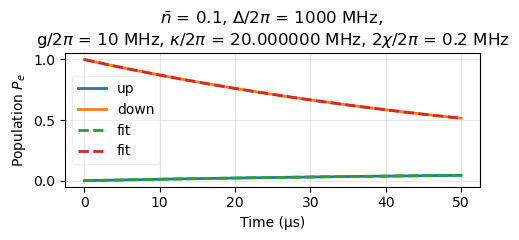

For nbar = 0.100:
Gamma_1 fit    = 15.101 kHz


In [37]:
t_fit = np.linspace(min(tlist), max(tlist), 500)
p_fit_g = exp_decay_up(t_fit, *popt_g)
p_fit_e = exp_decay_down(t_fit, *popt_e)
lw = 2

fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(tlist, pop_g, lw=lw, label=r"up")
ax.plot(tlist, pop_e, lw=lw, label=r"down")
ax.plot(t_fit, p_fit_g, "--", lw=lw, label=r"fit")
ax.plot(t_fit, p_fit_e, "--", lw=lw, label=r"fit")
# ax.axhline(Pss_g, color="k", ls="--", lw=1, label=r"$P_e^{ss}$")
ax.set_xlabel("Time (μs)")
ax.set_ylabel(r"Population $P_e$")
# ax.set_title(fr"Population evolution with thermal photons, $\bar{{n}}={n_th_demo}$")
ax.legend(framealpha=0.3)
plt.title(fr'$\bar{{n}}$ = 0.1, $\Delta/2\pi$ = {(Delta)/2/np.pi:.0f} MHz, '+'\n'+ 
fr'g/2$\pi$ = {g/2/np.pi:.0f} MHz, $\kappa$/2$\pi$ = {kappa/2/np.pi:f} MHz,'
+fr' 2$\chi$/2$\pi$ = {2*chi /(2*np.pi):.1f} MHz')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Gamma1_eff = (Gamma1_g + Gamma1_e)/2 
print(f"For nbar = {n_th:.3f}:")
print(f"Gamma_1 fit    = {Gamma1_eff *1e3:.3f} kHz")

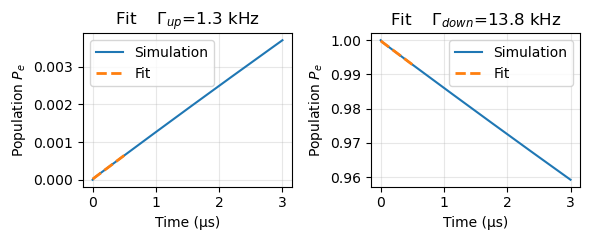



Fit Linear: Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Fit Linear: Gamma_up + Gamma_down = 15.1 kHz
Fit Exp: Gamma_1 = 15.1 kHz, Pss = 0.083
Fit Exp: Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Theory : Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Error: 0.0 kHz, 0.0 kHz


In [38]:
# 1) Population evolution for a fixed thermal occupation.
# n_th = 0.1
tlist = np.linspace(0, 3, int(1e3))  # us
# tlist = np.linspace(0, 1e-4, int(1e3))  # us
pop_g = simulate_population(n_th, tlist, qubit_init="g")
pop_e = simulate_population(n_th, tlist, qubit_init="e")

fit_tmax = 0.5 # 0.5  # us, short-time window for linear fitting

gamma_up_slope, gamma_down_slope, coef_g, coef_e, t_fit = fit_initial_rates(
    tlist, pop_g, pop_e, fit_tmax=fit_tmax
)

# gamma_up_slope, gamma_down_slope, t_fit = fit_initial_rates(
#     tlist, pop_g, pop_e, fit_tmax=fit_tmax
# )
# coef_g, coef_e = [gamma_up_slope,0],[-0.135,coef_e[1]]
# coef_g, coef_e = [gamma_up_slope,0],[-gamma_down_slope,1]

gamma_sum_slope = gamma_up_slope + gamma_down_slope

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
axes[0].plot(tlist, pop_g, label=r"Simulation")
axes[0].plot(t_fit, np.polyval(coef_g, t_fit), "--", lw=2, label=fr"Fit")
# axes[0].set_xlim(0, max(5 * fit_tmax, fit_tmax))
axes[0].set_xlabel("Time (μs)")
axes[0].set_ylabel(r"Population $P_e$")
axes[0].set_title(fr"Fit    $\Gamma_{{up}}$={gamma_up_slope * 1e3:.1f} kHz")
# axes[0].set_title(rf"Ideal $\Gamma_{{up}}$={gamma_up_ideal * 1e3:.1f} kHz "+
# "\n"+fr"Fit    $\Gamma_{{up}}$={gamma_up_slope * 1e3:.1f} kHz")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(tlist, pop_e, label=r"Simulation")
axes[1].plot(t_fit, np.polyval(coef_e, t_fit), "--", lw=2, label=fr"Fit")
# axes[1].set_xlim(0, max(5 * fit_tmax, fit_tmax))
axes[1].set_xlabel("Time (μs)")
axes[1].set_ylabel(r"Population $P_e$")
axes[1].set_title(fr"Fit    $\Gamma_{{down}}$={gamma_down_slope * 1e3:.1f} kHz")
# axes[1].set_title(rf"Ideal $\Gamma_{{down}}$={gamma_down_ideal * 1e3:.1f} kHz "+
# "\n"+fr"Fit    $\Gamma_{{down}}$={gamma_down_slope * 1e3:.1f} kHz")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()
# print(f"Short-time linear fit window: t <= {fit_tmax:.3f} us")
print(f"\n")
print(f"Fit Linear: Gamma_up = {gamma_up_slope * 1e3:.1f} kHz, Gamma_down = {gamma_down_slope * 1e3:.1f} kHz")
print(f"Fit Linear: Gamma_up + Gamma_down = {gamma_sum_slope * 1e3:.1f} kHz")
print(f"Fit Exp: Gamma_1 = {Gamma1_eff * 1e3:.1f} kHz, Pss = {Pss_g:.3f}")
# print(f"Relative difference = {(gamma_sum_slope / Gamma1_eff - 1) * 100:.1f} %")

print(f"Fit Exp: Gamma_up = {Gamma1_eff * 1e3*Pss_g:.1f} kHz, Gamma_down = {Gamma1_eff * 1e3*(1-Pss_g):.1f} kHz")
print(f"Theory : Gamma_up = {gamma_up_ideal * 1e3:.1f} kHz, Gamma_down = {gamma_down_ideal * 1e3:.1f} kHz")
print(f"Error: {abs(gamma_up_ideal - gamma_up_slope)*1e3:.1f} kHz, {abs(gamma_down_ideal - gamma_down_slope)*1e3:.1f} kHz")


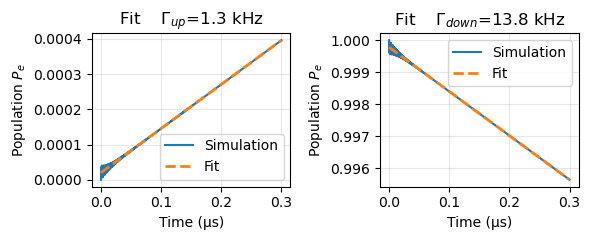



Fit Linear: Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Fit Linear: Gamma_up + Gamma_down = 15.0 kHz
Fit Exp: Gamma_1 = 15.1 kHz, Pss = 0.083
Fit Exp: Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Theory : Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Error: 0.0 kHz, 0.0 kHz


In [39]:
# 1) Population evolution for a fixed thermal occupation.
# n_th = 0.1
tlist = np.linspace(0, 0.3, int(1e3))  # us
# tlist = np.linspace(0, 1e-4, int(1e3))  # us
pop_g = simulate_population(n_th, tlist, qubit_init="g")
pop_e = simulate_population(n_th, tlist, qubit_init="e")

fit_tmax = 0.5 # 0.5  # us, short-time window for linear fitting

gamma_up_slope, gamma_down_slope, coef_g, coef_e, t_fit = fit_initial_rates(
    tlist, pop_g, pop_e, fit_tmax=fit_tmax
)

# gamma_up_slope, gamma_down_slope, t_fit = fit_initial_rates(
#     tlist, pop_g, pop_e, fit_tmax=fit_tmax
# )
# coef_g, coef_e = [gamma_up_slope,0],[-0.135,coef_e[1]]
# coef_g, coef_e = [gamma_up_slope,0],[-gamma_down_slope,1]

gamma_sum_slope = gamma_up_slope + gamma_down_slope

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
axes[0].plot(tlist, pop_g, label=r"Simulation")
axes[0].plot(t_fit, np.polyval(coef_g, t_fit), "--", lw=2, label=fr"Fit")
# axes[0].set_xlim(0, max(5 * fit_tmax, fit_tmax))
axes[0].set_xlabel("Time (μs)")
axes[0].set_ylabel(r"Population $P_e$")
axes[0].set_title(fr"Fit    $\Gamma_{{up}}$={gamma_up_slope * 1e3:.1f} kHz")
# axes[0].set_title(rf"Ideal $\Gamma_{{up}}$={gamma_up_ideal * 1e3:.1f} kHz "+
# "\n"+fr"Fit    $\Gamma_{{up}}$={gamma_up_slope * 1e3:.1f} kHz")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(tlist, pop_e, label=r"Simulation")
axes[1].plot(t_fit, np.polyval(coef_e, t_fit), "--", lw=2, label=fr"Fit")
# axes[1].set_xlim(0, max(5 * fit_tmax, fit_tmax))
axes[1].set_xlabel("Time (μs)")
axes[1].set_ylabel(r"Population $P_e$")
axes[1].set_title(fr"Fit    $\Gamma_{{down}}$={gamma_down_slope * 1e3:.1f} kHz")
# axes[1].set_title(rf"Ideal $\Gamma_{{down}}$={gamma_down_ideal * 1e3:.1f} kHz "+
# "\n"+fr"Fit    $\Gamma_{{down}}$={gamma_down_slope * 1e3:.1f} kHz")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()
# print(f"Short-time linear fit window: t <= {fit_tmax:.3f} us")
print(f"\n")
print(f"Fit Linear: Gamma_up = {gamma_up_slope * 1e3:.1f} kHz, Gamma_down = {gamma_down_slope * 1e3:.1f} kHz")
print(f"Fit Linear: Gamma_up + Gamma_down = {gamma_sum_slope * 1e3:.1f} kHz")
print(f"Fit Exp: Gamma_1 = {Gamma1_eff * 1e3:.1f} kHz, Pss = {Pss_g:.3f}")
# print(f"Relative difference = {(gamma_sum_slope / Gamma1_eff - 1) * 100:.1f} %")

print(f"Fit Exp: Gamma_up = {Gamma1_eff * 1e3*Pss_g:.1f} kHz, Gamma_down = {Gamma1_eff * 1e3*(1-Pss_g):.1f} kHz")
print(f"Theory : Gamma_up = {gamma_up_ideal * 1e3:.1f} kHz, Gamma_down = {gamma_down_ideal * 1e3:.1f} kHz")
print(f"Error: {abs(gamma_up_ideal - gamma_up_slope)*1e3:.1f} kHz, {abs(gamma_down_ideal - gamma_down_slope)*1e3:.1f} kHz")


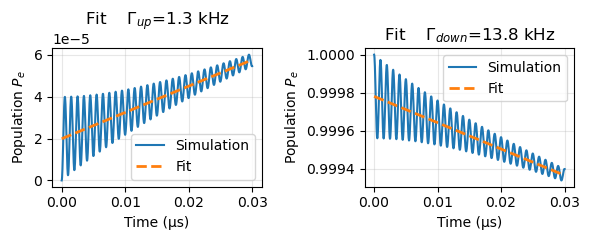



Fit Linear: Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Fit Linear: Gamma_up + Gamma_down = 15.1 kHz
Fit Exp: Gamma_1 = 15.1 kHz, Pss = 0.083
Fit Exp: Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Theory : Gamma_up = 1.3 kHz, Gamma_down = 13.8 kHz
Error: 0.0 kHz, 0.0 kHz


In [40]:
# 1) Population evolution for a fixed thermal occupation.
# n_th = 0.1
tlist = np.linspace(0, 0.03, int(1e3))  # us
# tlist = np.linspace(0, 1e-4, int(1e3))  # us
pop_g = simulate_population(n_th, tlist, qubit_init="g")
pop_e = simulate_population(n_th, tlist, qubit_init="e")

fit_tmax = 0.5 # 0.5  # us, short-time window for linear fitting

gamma_up_slope, gamma_down_slope, coef_g, coef_e, t_fit = fit_initial_rates(
    tlist, pop_g, pop_e, fit_tmax=fit_tmax
)

# gamma_up_slope, gamma_down_slope, t_fit = fit_initial_rates(
#     tlist, pop_g, pop_e, fit_tmax=fit_tmax
# )
# coef_g, coef_e = [gamma_up_slope,0],[-0.135,coef_e[1]]
# coef_g, coef_e = [gamma_up_slope,0],[-gamma_down_slope,1]

gamma_sum_slope = gamma_up_slope + gamma_down_slope

fig, axes = plt.subplots(1, 2, figsize=(6, 2.5))
axes[0].plot(tlist, pop_g, label=r"Simulation")
axes[0].plot(t_fit, np.polyval(coef_g, t_fit), "--", lw=2, label=fr"Fit")
# axes[0].set_xlim(0, max(5 * fit_tmax, fit_tmax))
axes[0].set_xlabel("Time (μs)")
axes[0].set_ylabel(r"Population $P_e$")
axes[0].set_title(fr"Fit    $\Gamma_{{up}}$={gamma_up_slope * 1e3:.1f} kHz")
# axes[0].set_title(rf"Ideal $\Gamma_{{up}}$={gamma_up_ideal * 1e3:.1f} kHz "+
# "\n"+fr"Fit    $\Gamma_{{up}}$={gamma_up_slope * 1e3:.1f} kHz")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(tlist, pop_e, label=r"Simulation")
axes[1].plot(t_fit, np.polyval(coef_e, t_fit), "--", lw=2, label=fr"Fit")
# axes[1].set_xlim(0, max(5 * fit_tmax, fit_tmax))
axes[1].set_xlabel("Time (μs)")
axes[1].set_ylabel(r"Population $P_e$")
axes[1].set_title(fr"Fit    $\Gamma_{{down}}$={gamma_down_slope * 1e3:.1f} kHz")
# axes[1].set_title(rf"Ideal $\Gamma_{{down}}$={gamma_down_ideal * 1e3:.1f} kHz "+
# "\n"+fr"Fit    $\Gamma_{{down}}$={gamma_down_slope * 1e3:.1f} kHz")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()
# print(f"Short-time linear fit window: t <= {fit_tmax:.3f} us")
print(f"\n")
print(f"Fit Linear: Gamma_up = {gamma_up_slope * 1e3:.1f} kHz, Gamma_down = {gamma_down_slope * 1e3:.1f} kHz")
print(f"Fit Linear: Gamma_up + Gamma_down = {gamma_sum_slope * 1e3:.1f} kHz")
print(f"Fit Exp: Gamma_1 = {Gamma1_eff * 1e3:.1f} kHz, Pss = {Pss_g:.3f}")
# print(f"Relative difference = {(gamma_sum_slope / Gamma1_eff - 1) * 100:.1f} %")

print(f"Fit Exp: Gamma_up = {Gamma1_eff * 1e3*Pss_g:.1f} kHz, Gamma_down = {Gamma1_eff * 1e3*(1-Pss_g):.1f} kHz")
print(f"Theory : Gamma_up = {gamma_up_ideal * 1e3:.1f} kHz, Gamma_down = {gamma_down_ideal * 1e3:.1f} kHz")
print(f"Error: {abs(gamma_up_ideal - gamma_up_slope)*1e3:.1f} kHz, {abs(gamma_down_ideal - gamma_down_slope)*1e3:.1f} kHz")


In [41]:
k_up = (pop_g[-1]-pop_g[0]) / (tlist[-1]-tlist[0])
k_down = (pop_e[-1]-1) / (tlist[-1]-tlist[0])
# k_down = (pop_e[-1]-pop_e[0]) / (tlist[-1]-tlist[0])
print(f'k_up = {k_up:.3f}, k_down = {k_down:.3f}')

k_up = 0.002, k_down = -0.020


In [42]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

## box mode in 2021 PRXQ

In [ ]:
### 2018 PRL
gamma = 1.6e3 
chi = 0.45e6 * 2*np.pi
kappa = 1.5e6 * 2*np.pi
n = gamma* kappa / (4* chi**2) * (kappa**2 + 4* chi**2) / kappa**2
n

In [ ]:
## 2021 PRX Quantum
alpha = 7/25 /0.06
alpha

In [ ]:
## 2021 PRX Quantum
alpha = 4.67e6  # Hz / W
beta = 1e6 * 2*np.pi # Hz / W
kappa = 20e6 * 2*np.pi
wm = 17.18e9 * 2*np.pi
wq = 2.9531e9 * 2*np.pi

g = ( beta * kappa * (wm - wq) / (4* alpha) )**0.5
g / (2*np.pi * 1e6)

In [ ]:
## 2021 PRX Quantum
alpha = 4.67e6  # Hz / W
beta = 1e6 # Hz / W
kappa = 20e6 * 2*np.pi
wm = 17.18e9 * 2*np.pi
wq = 2.9531e9 * 2*np.pi

g = ( beta * kappa * (wm - wq) / (4* alpha) )**0.5
g / (2*np.pi * 1e6)

In [ ]:
## 2021 PRX Quantum
alpha = 4.67e6  # Hz / W
beta = 1e6 # Hz / W
kappa = 20e6 * 2*np.pi
wm = 17.18e9 * 2*np.pi
wq = 2.9531e9 * 2*np.pi

g = ( beta * kappa * (wm - wq) / (4* alpha) )**0.5
g / (2*np.pi * 1e6)

In [ ]:

# Plot ranges for normalized axes: x = k/(2pi), y = c/(2pi)
k_norm = np.logspace(0, 6, 500)  # 1e0 to 1e6
c_norm = np.logspace(0, 6, 500)  # 1e0 to 1e6
K_norm, C_norm = np.meshgrid(k_norm, c_norm)

# Convert normalized axes back to physical k, c for the formula
K = 2 * np.pi * K_norm
C = 2 * np.pi * C_norm

# gamma / n = (k**2 / (k**2 + 4*c**2)) * (4*c**2 / k)
gamma_over_n = (K**2 / (K**2 + 4 * C**2)) * (4 * C**2 / K)

# Guard against exact zeros/non-positive values for logarithmic color scaling
gamma_over_n = np.clip(gamma_over_n, 1e-300, None)

fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(
    K_norm,
    C_norm,
    gamma_over_n,
    shading='auto',
    cmap='bwr',
    norm=LogNorm(vmin=np.nanmin(gamma_over_n), vmax=np.nanmax(gamma_over_n))
)

# Log scales for both axes
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e0, 1e6)
ax.set_ylim(1e0, 1e6)

# Guideline: k = 2c  ->  k/(2pi) = 2 * c/(2pi)
y_line = np.logspace(0, 6, 500)
x_line = 2 * y_line
mask = (x_line >= 1e0) & (x_line <= 1e6)
ax.plot(x_line[mask], y_line[mask], 'k--', lw=1.5, label='k = 2c')

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('gamma / n (log scale)')

ax.set_xlabel('k / (2pi)')
ax.set_ylabel('c / (2pi)')
ax.set_title(r'$\gamma/n = \frac{k^2}{k^2 + 4c^2}\cdot\frac{4c^2}{k}$')
ax.legend(loc='best')

plt.tight_layout()
plt.show()